# BPM Detection Module

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from aft.utils.paths import  data_dir
from aft.bpm import BPMAnalysisConfig, analyze_bpm, analyze_and_tag_bpm

In [3]:
file_path = data_dir("NTFO - Acelstalalt.mp3")

## Direct approach: no preprocessing (fastest)

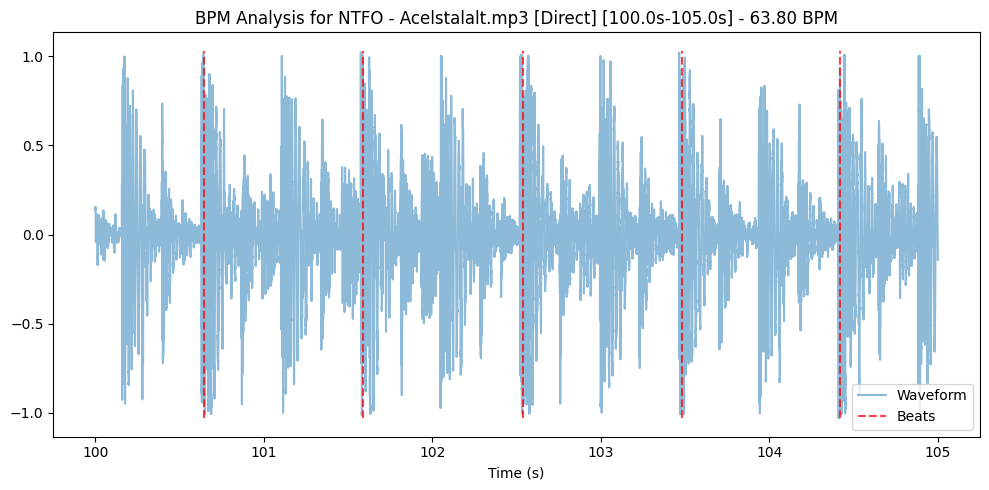

Path: c:\Users\aleja\Projects\audio-files-tagging\data\NTFO - Acelstalalt.mp3
duration: 483.77954648526077 seconds
samples: 21334678
BPM: 63.802083333333336
Confidence: 0.25991272926330566


In [4]:
config = BPMAnalysisConfig(
    sr=None, # Use original sample rate
    hop_length=512,
    tightness=400,
)

result = analyze_bpm(
    file_path,
    use_hpss=False,
    use_onset_strength=False,
    config=config,
    plot=True,
    xlim=(100, 105)
)

print(f"Path: {result['file_path']}")
print(f"duration: {result['duration']} seconds")
print(f"samples: {result['samples']}")
print(f"BPM: {result['bpm']}")
print(f"Confidence: {result['confidence']}")

## Only use HPSS but skip onset strength

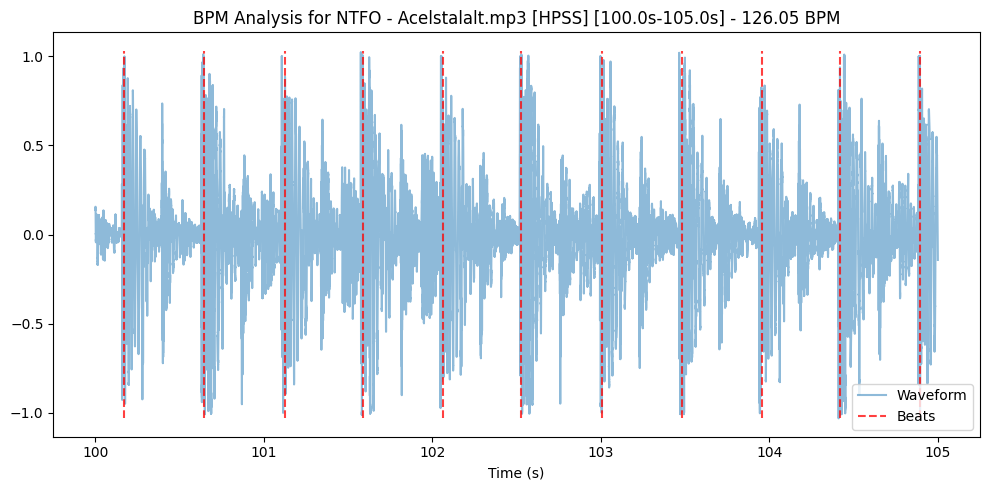

Path: c:\Users\aleja\Projects\audio-files-tagging\data\NTFO - Acelstalalt.mp3
duration: 483.77954648526077 seconds
samples: 21334678
BPM: 126.04801829268293
Confidence: 0.2636152505874634


In [5]:
result = analyze_bpm(
    file_path,
    use_hpss=True,
    use_onset_strength=False,
    config=config,
    plot=True,
    xlim=(100, 105)
)

print(f"Path: {result['file_path']}")
print(f"duration: {result['duration']} seconds")
print(f"samples: {result['samples']}")
print(f"BPM: {result['bpm']}")
print(f"Confidence: {result['confidence']}")

## Only use onset strength but skip HPSS

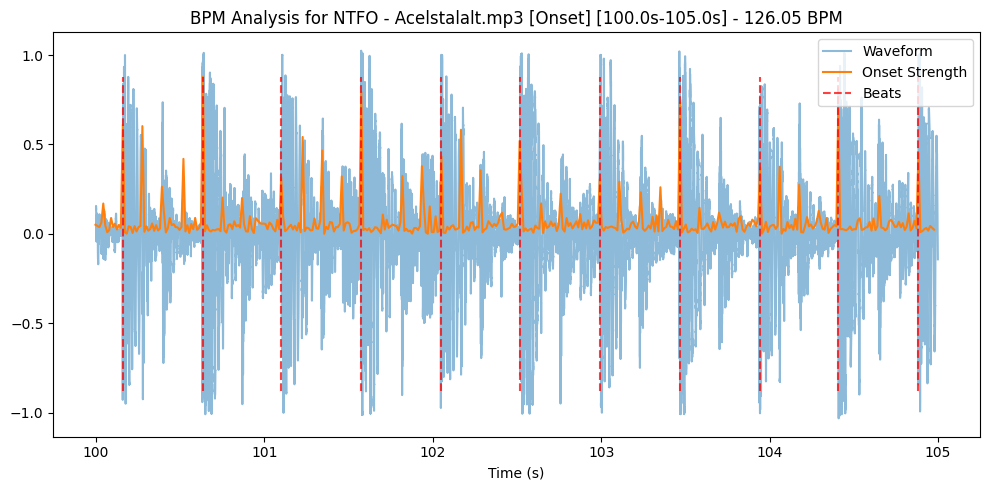

Path: c:\Users\aleja\Projects\audio-files-tagging\data\NTFO - Acelstalalt.mp3
duration: 483.77954648526077 seconds
samples: 21334678
BPM: 126.04801829268293
Confidence: 0.07365256547927856


In [6]:
config = BPMAnalysisConfig(
    sr=None, # Use original sample rate
    hop_length=512,
    tightness=400,
    n_fft=512,
    fmax=5000.0,
    n_mels=32,
)

result = analyze_bpm(
    file_path,
    use_hpss=False,
    use_onset_strength=True,
    config=config,
    plot=True,
    xlim=(100, 105)
)

print(f"Path: {result['file_path']}")
print(f"duration: {result['duration']} seconds")
print(f"samples: {result['samples']}")
print(f"BPM: {result['bpm']}")
print(f"Confidence: {result['confidence']}")

## Use both HPSS and onset strength (most accurate)

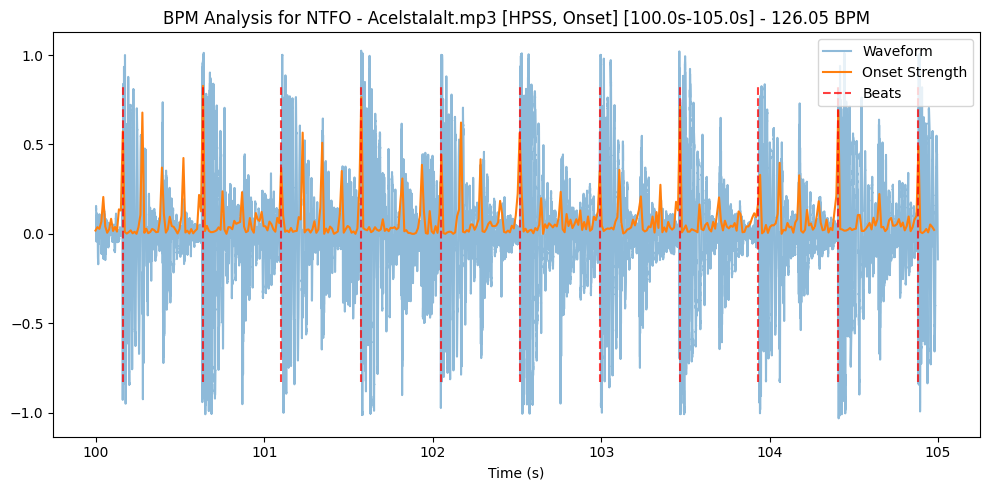

Path: c:\Users\aleja\Projects\audio-files-tagging\data\NTFO - Acelstalalt.mp3
duration: 483.77954648526077 seconds
samples: 21334678
BPM: 126.04801829268293
Confidence: 0.0


In [7]:
result = analyze_bpm(
    file_path,
    use_hpss=True,
    use_onset_strength=True,
    config=config,
    plot=True,
    xlim=(100, 105)
)

print(f"Path: {result['file_path']}")
print(f"duration: {result['duration']} seconds")
print(f"samples: {result['samples']}")
print(f"BPM: {result['bpm']}")
print(f"Confidence: {result['confidence']}")

## Tagging results

In [10]:
result = analyze_and_tag_bpm(file_path, write_tag=True)
print(f"Detected BPM: {result['bpm']:.2f} (confidence: {result['confidence']:.2%})")

Detected BPM: 126.05 (confidence: 0.00%)
